In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [4]:
df = pd.read_csv("../data/canteen_sales.csv")

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (289525, 17)


,date,time_slot,day_of_week,month,item,category,price,quantity_sold,revenue,is_saturday,is_sunday,is_exam_period,is_holiday,weather,temperature,rainfall,college_event
0,2025-07-01,08:00:00,Tuesday,7,Vada Pav,Snacks,20,35,700,0,0,0,0,Cloudy,23.66,1.56,0
1,2025-07-01,08:00:00,Tuesday,7,Samosa,Snacks,15,33,495,0,0,0,0,Cloudy,23.66,1.56,0
2,2025-07-01,08:00:00,Tuesday,7,Kachori,Snacks,20,20,400,0,0,0,0,Cloudy,23.66,1.56,0
3,2025-07-01,08:00:00,Tuesday,7,Misal Pav,Snacks,50,15,750,0,0,0,0,Cloudy,23.66,1.56,0
4,2025-07-01,08:00:00,Tuesday,7,Bread Pakoda,Snacks,25,15,375,0,0,0,0,Cloudy,23.66,1.56,0


In [5]:
# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Extract useful date features
df["day_of_week"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

# Convert time_slot to datetime
df["time_slot"] = pd.to_datetime(
    df["time_slot"],
    format="%H:%M:%S"
)

# Extract time features
df["hour"] = df["time_slot"].dt.hour
df["minute"] = df["time_slot"].dt.minute

# Create time index
df["time_index"] = (
    df["hour"] * 60 + df["minute"]
)

# Remove columns we decided not to use
df = df.drop(
    columns=[
        "date",
        "time_slot",
        "year",
        "day_of_month",
        "day_of_year",
        "rainfall",
        "temperature"
    ],
    errors="ignore"
)

print("Features prepared successfully.")

print("\nColumns:")
print(df.columns.tolist())

Features prepared successfully.

Columns:
['day_of_week', 'month', 'item', 'category', 'price', 'quantity_sold', 'revenue', 'is_saturday', 'is_sunday', 'is_exam_period', 'is_holiday', 'weather', 'college_event', 'hour', 'minute', 'time_index']


In [6]:
X = df.drop(
    columns=["quantity_sold","revenue"]
)

y = df["quantity_sold"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

Feature shape: (289525, 14)
Target shape: (289525,)

Features:
['day_of_week', 'month', 'item', 'category', 'price', 'is_saturday', 'is_sunday', 'is_exam_period', 'is_holiday', 'weather', 'college_event', 'hour', 'minute', 'time_index']


In [7]:
categorical_columns = [
    "item",
    "category",
    "weather"
]

X_encoded = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=False
)

print("Original feature count:", X.shape[1])
print("Encoded feature count:", X_encoded.shape[1])

Original feature count: 14
Encoded feature count: 44


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 231620
Testing samples: 57905


In [9]:
models = {

    "Linear Regression": LinearRegression(),

    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=42
    )
}


trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(
        X_train,
        y_train
    )

    trained_models[name] = model

print("\nAll models trained successfully.")

Training Linear Regression...
Training Decision Tree...
Training Random Forest...
Training Gradient Boosting...

All models trained successfully.


In [10]:
results = []

for name, model in trained_models.items():

    # Make predictions
    predictions = model.predict(X_test)

    # Calculate metrics
    mae = mean_absolute_error(
        y_test,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )

    r2 = r2_score(
        y_test,
        predictions
    )

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })


# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Sort by R²
results_df = results_df.sort_values(
    "R2",
    ascending=False
).reset_index(drop=True)

results_df

,Model,MAE,RMSE,R2
0,Random Forest,2.776187,4.488996,0.961345
1,Decision Tree,3.294560,5.328883,0.945527
2,Gradient Boosting,4.490471,9.355960,0.832088
3,Linear Regression,10.068933,18.569955,0.338505


In [13]:
# =========================
# CROSS-VALIDATION
# =========================

from sklearn.model_selection import cross_val_score

rf_cv = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

cv_scores = cross_val_score(
    rf_cv,
    X_encoded,
    y,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

print("Cross-validation R² scores:")
print(cv_scores)

print("\nAverage R²:")
print(cv_scores.mean())

print("\nStandard deviation:")
print(cv_scores.std())

Cross-validation R² scores:
[0.95541463 0.95666989 0.95768349 0.95750444 0.96410647]

Average R²:
0.9582757826036057

Standard deviation:
0.0030235013488203824


In [14]:
# =========================
# RANDOM FOREST
# HYPERPARAMETER TUNING
# =========================

from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

param_grid = {
    "n_estimators": [100, 150, 200],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(
    X_train,
    y_train
)

print("\nBest parameters:")
print(random_search.best_params_)

print("\nBest cross-validation R²:")
print(random_search.best_score_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best parameters:
{'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_depth': 20}

Best cross-validation R²:
0.9671763024476023


In [15]:
import xgboost

print(xgboost.__version__)

3.4.1


In [16]:
# =========================
# XGBOOST BASELINE
# =========================

from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train,
    y_train
)

# Predictions
xgb_predictions = xgb_model.predict(
    X_test
)

print("First 10 predictions:")
print(xgb_predictions[:10])

print("\nFirst 10 actual values:")
print(y_test.iloc[:10].values)

First 10 predictions:
[18.344416   1.4392897  5.643788  11.988962  64.51387   15.705596
 16.189894  56.125156   2.1659045 22.179005 ]

First 10 actual values:
[14  2  9  9 78 17 18 52  2 22]


In [17]:
# =========================
# XGBOOST PERFORMANCE
# =========================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("XGBoost Performance")
print("-------------------------")
print(f"MAE : {xgb_mae:.4f}")
print(f"RMSE: {xgb_rmse:.4f}")
print(f"R²  : {xgb_r2:.4f}")

XGBoost Performance
-------------------------
MAE : 2.7263
RMSE: 4.8429
R²  : 0.9550


In [18]:
# =========================
# BEST RANDOM FOREST MODEL
# =========================

best_rf = random_search.best_estimator_

print("Best Random Forest:")
print(best_rf)

Best Random Forest:
RandomForestRegressor(max_depth=20, min_samples_split=10, n_estimators=200,
                      n_jobs=-1, random_state=42)


In [19]:
# =========================
# FEATURE IMPORTANCE
# =========================

import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,time_index,0.497524
2,price,0.126838
6,is_holiday,0.100129
0,day_of_week,0.045472
3,is_saturday,0.041694
8,hour,0.035656
42,weather_Rainy,0.021908
29,item_Tea,0.018214
19,item_Kachori,0.014064
15,item_Cold Drink,0.012882


In [20]:
# =========================
# TOP 10 FEATURES
# =========================

top_features = feature_importance.head(10)

top_features

,Feature,Importance
10,time_index,0.497524
2,price,0.126838
6,is_holiday,0.100129
0,day_of_week,0.045472
3,is_saturday,0.041694
8,hour,0.035656
42,weather_Rainy,0.021908
29,item_Tea,0.018214
19,item_Kachori,0.014064
15,item_Cold Drink,0.012882


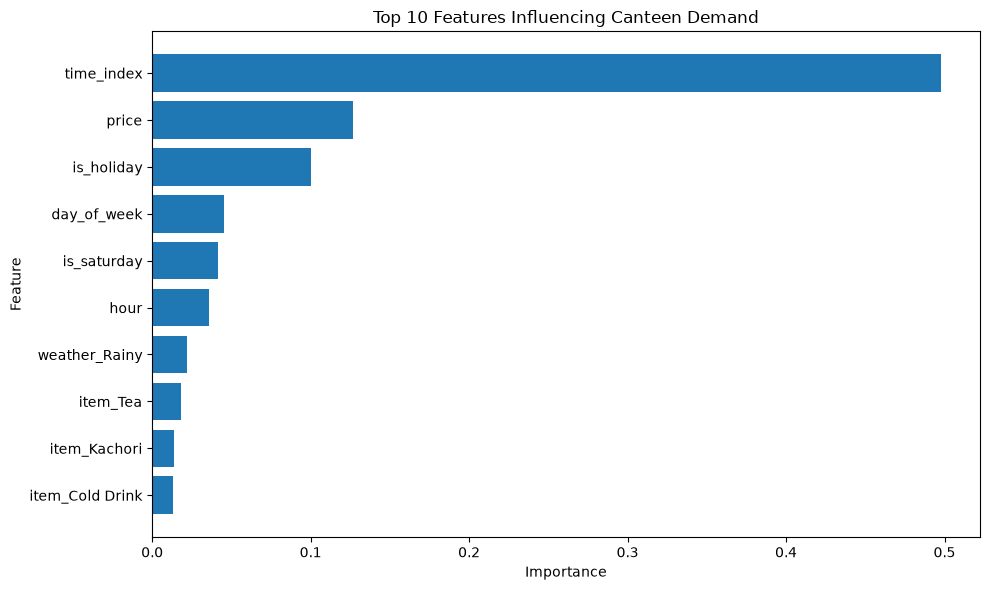

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Features Influencing Canteen Demand")

plt.tight_layout()
plt.show()

In [23]:
print("Features currently being used:")
print(X.columns.tolist())

print("\nIs revenue included?")
print("revenue" in X.columns)

Features currently being used:
['day_of_week', 'month', 'item', 'category', 'price', 'is_saturday', 'is_sunday', 'is_exam_period', 'is_holiday', 'weather', 'college_event', 'hour', 'minute', 'time_index']

Is revenue included?
False
